In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf
import numpy as np
import OpenDartReader
from datetime import datetime
import os
from dotenv import load_dotenv
import time

In [320]:
# SK하이닉스의 데이터를 수집 
hynix = yf.Ticker("000660.KS")
# 최근 2년간의 데이터를 추출 
df = hynix.history(period='12y')
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-05-26 00:00:00+09:00,36715.772958,36845.053849,36500.304807,36543.398438,1337761,0.0,0.0
2014-05-27 00:00:00+09:00,36715.768532,36758.862157,36241.738656,36371.019531,1206673,0.0,0.0
2014-05-28 00:00:00+09:00,36845.042570,36845.042570,36543.387251,36715.761719,2267797,0.0,0.0
2014-05-29 00:00:00+09:00,36801.948953,36974.323421,36586.480868,36715.761719,2788250,0.0,0.0
2014-05-30 00:00:00+09:00,36715.777003,38051.679688,36715.777003,38051.679688,5719933,0.0,0.0


In [321]:
df = df.loc[df.index >= '2015-01-01']

In [322]:
df = df[ ['Close', 'Volume'] ]
df['MA20'] = df['Close'].rolling(20).mean()

In [135]:
load_dotenv()
api_key = os.getenv('api_key')

In [325]:
df.index = df.index.tz_localize(None)

In [137]:
dart = OpenDartReader(api_key)

In [138]:
current_year = datetime.now().year
years = list(range(2015, current_year+1))
years

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

In [139]:
reprt_codes = ['11013', '11012', '11014', '11011']
dart_data_list = []

In [140]:
for year in years:
    for code in reprt_codes:
        try : 
            report = dart.finstate('000660', year, code)
            if report is not None:
                op_profit = report[ (report['fs_div'] == 'CFS')  & ( report['account_nm'] == '영업이익' ) ]
                if not op_profit.empty:
                    val = int(
                            op_profit['thstrm_amount'].values[0].replace(',', '')
                        )
                    # code 11013 -> 1분기 보고서 
                    if code == '11013' : d = f"{year}-05-15"
                    elif code == '11012' : d = f"{year}-08-14"
                    elif code == '11014' : d = f"{year}-11-14"
                    else : d = f"{year+1}-03-31"

                    report_date = pd.to_datetime(d)
                    if report_date <= datetime.now():
                        dart_data_list.append({'Date' : report_date, 'Operation_Profit' : val})
            time.sleep(1)
        except: continue
dart_data_list

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}



[{'Date': Timestamp('2016-03-31 00:00:00'), 'Operation_Profit': 5336100000000},
 {'Date': Timestamp('2016-05-15 00:00:00'), 'Operation_Profit': 561798000000},
 {'Date': Timestamp('2016-08-14 00:00:00'), 'Operation_Profit': 452853000000},
 {'Date': Timestamp('2016-11-14 00:00:00'), 'Operation_Profit': 725956000000},
 {'Date': Timestamp('2017-03-31 00:00:00'), 'Operation_Profit': 3276746000000},
 {'Date': Timestamp('2017-05-15 00:00:00'), 'Operation_Profit': 2467599000000},
 {'Date': Timestamp('2017-08-14 00:00:00'), 'Operation_Profit': 3050700000000},
 {'Date': Timestamp('2017-11-14 00:00:00'), 'Operation_Profit': 3737193000000},
 {'Date': Timestamp('2018-03-31 00:00:00'),
  'Operation_Profit': 13721326000000},
 {'Date': Timestamp('2018-05-15 00:00:00'), 'Operation_Profit': 4367338000000},
 {'Date': Timestamp('2018-08-14 00:00:00'), 'Operation_Profit': 5573918000000},
 {'Date': Timestamp('2018-11-14 00:00:00'), 'Operation_Profit': 6472420000000},
 {'Date': Timestamp('2019-03-31 00:00:00

In [141]:
dart_df = pd.DataFrame(dart_data_list)
dart_df

,Date,Operation_Profit
0,2016-03-31,5336100000000
1,2016-05-15,561798000000
2,2016-08-14,452853000000
3,2016-11-14,725956000000
4,2017-03-31,3276746000000
5,2017-05-15,2467599000000
6,2017-08-14,3050700000000
7,2017-11-14,3737193000000
8,2018-03-31,13721326000000
9,2018-05-15,4367338000000


In [323]:
df2 = df.reset_index()

In [326]:
df = pd.merge_asof(df, dart_df, left_index=True, right_on='Date', direction='backward')

In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2792 entries, 2015-01-02 to 2026-05-26
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Close             2792 non-null   float64       
 1   Volume            2792 non-null   int64         
 2   MA20              2773 non-null   float64       
 3   Date              2792 non-null   datetime64[ns]
 4   Operation_Profit  2484 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 130.9 KB


In [348]:
df.dropna(inplace=True)

In [349]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2484 entries, 2016-03-31 to 2026-05-26
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Close             2484 non-null   float64       
 1   Volume            2484 non-null   int64         
 2   MA20              2484 non-null   float64       
 3   Date              2484 non-null   datetime64[ns]
 4   Operation_Profit  2484 non-null   float64       
 5   Dist_MA20         2484 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 135.8 KB


In [350]:
df['Dist_MA20'] = ( df['Close'] - df['MA20'] ) / df['MA20']

In [351]:
x = df[['Close', 'Volume', 'Operation_Profit', 'Dist_MA20']].values
# x = df[['Close']].values
y = df[['Close']].values

In [352]:
split_idx = int(len(df) * 0.85)
X_train, X_test = x[ : split_idx], x[split_idx : ]
Y_train, Y_test = y[ : split_idx], y[split_idx : ]
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(2111, 4) (373, 4)
(2111, 1) (373, 1)


In [353]:
X_train

array([[ 2.48191738e+04,  4.33658100e+06,  5.33610000e+12,
        -5.67143415e-02],
       [ 2.48632559e+04,  2.99143100e+06,  5.33610000e+12,
        -4.91443912e-02],
       [ 2.45987539e+04,  2.82308800e+06,  5.33610000e+12,
        -5.28727491e-02],
       ...,
       [ 1.90847422e+05,  3.56031000e+06,  5.46853600e+12,
         1.35082265e-02],
       [ 1.93415750e+05,  3.46036100e+06,  5.46853600e+12,
         2.23741937e-02],
       [ 1.93415750e+05,  2.97654600e+06,  5.46853600e+12,
         1.99510061e-02]], shape=(2111, 4))

In [354]:
# 초기 설정 값
# 시계열 데이터의 구간(과거 데이터의 개수)
window = 60
# 학습 루프에서 루프의 수 
epochs = 20
# 학습 데이터의 배치의 개수
x_batch = 32
y_batch = 32
# optimizer lr 값 (학습율)
lr = 0.001
# 은닉 층의 뉴런의 개수 
hidden_cnt = 64
# 랜덤의 일반화
torch.manual_seed(42)
# 은닉층, 셀 사용 여부
head_type = 'c'

In [355]:
class WindowDataset(Dataset):
    # 입력 데이터와 타깃 데이터를 받아서 
    # 구간의 수만큼 입력데이터를 잘라주고 
    # 해당 구간 바로 다음 행의 타깃 데이터를 생성
    # 구간의 데이터와 다음행의 타깃 데이터를 되돌려준다
    # DataLoader 클래스에서 사용하기 위함
    def __init__(
            self, _x, _y, _window
    ):
        self.x = _x
        self.y = _y
        self.window = _window
        # n의 값은 구간의 데이터 시작 지점의 최대값
        self.n = len(_x) - _window
    
    def __len__(self):
        # window 의 수치가 x의 길이보다 큰 경우에는 1을 되돌려준다. 
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        # idx : 구간의 시점 지점 -> 최대 값은 self.n
        # idx부터 idx+window-1 지점까지의 데이터 -> (window, 2)
        x_window = self.x[idx : idx + self.window]
        # idx+window 위치의 데이터  -> 단일값 생성
        y_next = self.y[idx + self.window]
        # tensor형의 변환 
        x_tensor = torch.tensor(x_window)
        y_tensor = torch.tensor(y_next)

        return x_tensor, y_tensor

In [356]:
# 데이터들 스케일링 -> MinMaxScaler
x_scaler = MinMaxScaler().fit(X_train)
y_scaler = MinMaxScaler().fit(Y_train)

X_train = x_scaler.transform(X_train)
X_test = x_scaler.transform(X_test)
Y_train = y_scaler.transform(Y_train)
Y_test = y_scaler.transform(Y_test)

In [357]:
# WindowDataset 생성 
# 객체을 생성하고 getitem() 함수를 사용한다면 window(60) 구간의 데이터와
# 해당 구간 다음 행의 종가 데이터를 되돌려주는 class
train_ds = WindowDataset(X_train, Y_train, window)
test_ds = WindowDataset(X_test, Y_test, window)

In [358]:
# Dataloader -> WindowDataset  class를 이용하여 
# ds_data에서 len() 함수를 이용하여 해당 구간에서 가장 마지막에 사용 가능한 시작 지점

train_dl = DataLoader(train_ds, shuffle=True, drop_last= True, 
                      batch_size=x_batch)
test_dl = DataLoader(test_ds, shuffle=False, drop_last = False, 
                     batch_size=y_batch)

In [359]:
# LSTM 모델 정의 

class LSTMReg(nn.Module):
    def __init__(
            self, 
            input_size, hidden_size, 
            num_layers = 1, dropout = 0.0, 
            bidirectional = False, head_type = 'h'
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size = input_size, 
            hidden_size= hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first=True
        )

        out_dim = hidden_size * (2 if bidirectional else 1)
        # head_type은 은닉층만 사용하거나 셀만 사용 -> 차원의 개수 * 1 
        if head_type in ['h', 'c']:
            head_in = out_dim
        elif head_type == 'h_c':
            head_in  = out_dim * 2
        else:
            print('head_type Error')

        self.head = nn.Sequential(
            nn.Linear(head_in , 1)
        )
        self.head_type = head_type
    
    # 순전파 함수 
    def forward(self, x):
        # 순전파의 예측 결과 값
        out, (h_n, c_n) = self.lstm(x)
        # 은닉층 중 마지막 은닉층을 저장 
        h_last = h_n[-1]
        # 셀 마지막 셀 
        c_last = torch.tanh(c_n[-1])

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat( [h_last, c_last], dim = -1 )
        
        return self.head(feat)

In [360]:
model = LSTMReg(input_size=x.shape[1], hidden_size=hidden_cnt, head_type=head_type)
model

LSTMReg(
  (lstm): LSTM(4, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [361]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

In [362]:

@torch.no_grad()
def evaluate_mse(dl):
    model.eval()
    total_loss = 0.0
    total_n = 0
    for x, y in dl:
        x = x.float()
        y = y.float()
        # 예측
        pred = model(x)
        # 예측 값과 실젯값의 loss 확인 
        loss = criterion(pred, y)   # 평균 손실 데이터 
        # 평균 손실 * y의 크기 -> 총 손실을 누적합 
        total_loss += loss.item() * y.size(0)
        # 총 개수을 누적합
        total_n += y.size(0)
    # 함수에서 되돌려주는 결과 값 -> total_loss / total_n
    # dl의 barch_size가 0인경우라면 -> 0 / 0 --> Error 발생 -> 분모는 max() 이용
    return total_loss / max(total_n, 1)


In [363]:
# 학습 루프 (반복 학습) : (순전파 -> 손실 -> 역전파 -> 옵티마이저) -> 하나의 스탭 
# loss의 값의 변화를 저장 
train_history = []
test_history = []

# 반복 횟수에 따른 반복문이 생성 
for epoch in range(epochs):
    # 모델의 학습 모드 변환
    model.train()
    # 총 손실에 대한 평균을 구하기 위해서 총 로스, 총 개수의 초기값을 설정
    tot_loss = 0.0
    tot_n = 0
    # train인 DataLoader를 이용하여 반복문을 실행 
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        # 학습 루프가 반복적으로 실행이 되기 때문에 미분의 값을 초기화
        optimizer.zero_grad()
        # 모델에 학습 데이터를 학습하여 예측
        pred = model(x)
        # 예측값과 실젯값의 차이를 계산
        loss = criterion(pred, y)
        # 역전
        loss.backward()
        # 기울기 너무 급격하게 변화해서 폭주하는 상황은 방지 
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        # 총 손실의 누적합 
        tot_loss += loss.item() * y.size(0)
        # 총 개수의 누적합 
        tot_n += y.size(0)
    
    # train 데이터에 총 loss의 평균 
    train_loss = tot_loss / max(tot_n , 1)
    # test 데이터에 총 loss의 평균
    # 학습모드와 평가모드를 루프에서 동시에 사용하는 이유는 -> 과적합 방지 
    test_loss = evaluate_mse(test_dl)
    # loss의 내역을 저장 
    train_history.append(train_loss)
    test_history.append(test_loss)
    print(f"Epoch : {epoch + 1}, train_mse : {round(train_loss, 4)}, \
          test_mse : {round(test_loss, 4)}")



Epoch : 1, train_mse : 0.0237,           test_mse : 2.6501
Epoch : 2, train_mse : 0.0012,           test_mse : 2.7893
Epoch : 3, train_mse : 0.0004,           test_mse : 2.933
Epoch : 4, train_mse : 0.0003,           test_mse : 2.9276
Epoch : 5, train_mse : 0.0003,           test_mse : 2.8781
Epoch : 6, train_mse : 0.0003,           test_mse : 2.8557
Epoch : 7, train_mse : 0.0003,           test_mse : 2.8375
Epoch : 8, train_mse : 0.0003,           test_mse : 2.7874
Epoch : 9, train_mse : 0.0003,           test_mse : 2.7416
Epoch : 10, train_mse : 0.0003,           test_mse : 2.7575
Epoch : 11, train_mse : 0.0002,           test_mse : 2.7096
Epoch : 12, train_mse : 0.0003,           test_mse : 2.687
Epoch : 13, train_mse : 0.0002,           test_mse : 2.6127
Epoch : 14, train_mse : 0.0002,           test_mse : 2.596
Epoch : 15, train_mse : 0.0002,           test_mse : 2.5629
Epoch : 16, train_mse : 0.0002,           test_mse : 2.5744
Epoch : 17, train_mse : 0.0002,           test_mse :

In [364]:
# 검증 예측 , 실제 값을 그래프로 시각화 
model.eval()
# 예측 값, 실제 값을 1차원 리스트에 대입
preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        pred = model(x).cpu()
        preds.append(pred)
        trues.append(y)
preds = torch.cat(preds, dim=0).numpy()
trues = torch.cat(trues, dim=0).numpy()
# preds, tures 아직 스케일링이 되어있는 상태

# 데이터의 역변환
preds_origin = y_scaler.inverse_transform(preds).squeeze()
trues_origin = y_scaler.inverse_transform(trues).squeeze()

In [365]:
preds_origin

array([196147.67, 195574.38, 194860.33, 198067.27, 200712.4 , 203103.38,
       203847.94, 207468.78, 207459.61, 206635.34, 204446.16, 201424.06,
       200574.45, 199184.61, 194525.53, 189880.55, 189814.78, 189620.36,
       189396.52, 187391.48, 185891.77, 189285.02, 191800.1 , 195433.56,
       198471.31, 199259.25, 200719.69, 203571.56, 207294.14, 208588.9 ,
       207976.81, 209778.75, 208121.39, 203950.9 , 197799.9 , 195874.1 ,
       194682.84, 192227.12, 185210.12, 174050.58, 169381.61, 164490.52,
       168922.58, 171092.47, 172098.55, 172836.78, 170480.47, 169491.02,
       169168.27, 169701.03, 168935.39, 171516.44, 172192.06, 175219.78,
       176144.17, 176314.58, 175068.14, 177789.72, 181397.89, 183108.31,
       184182.62, 186742.14, 189586.69, 194318.36, 194919.34, 197562.  ,
       197331.45, 198276.34, 198392.84, 196982.73, 197256.73, 198581.42,
       199110.58, 201403.67, 204464.48, 203378.42, 204130.11, 208158.23,
       213324.3 , 218582.27, 222425.75, 228272.19, 

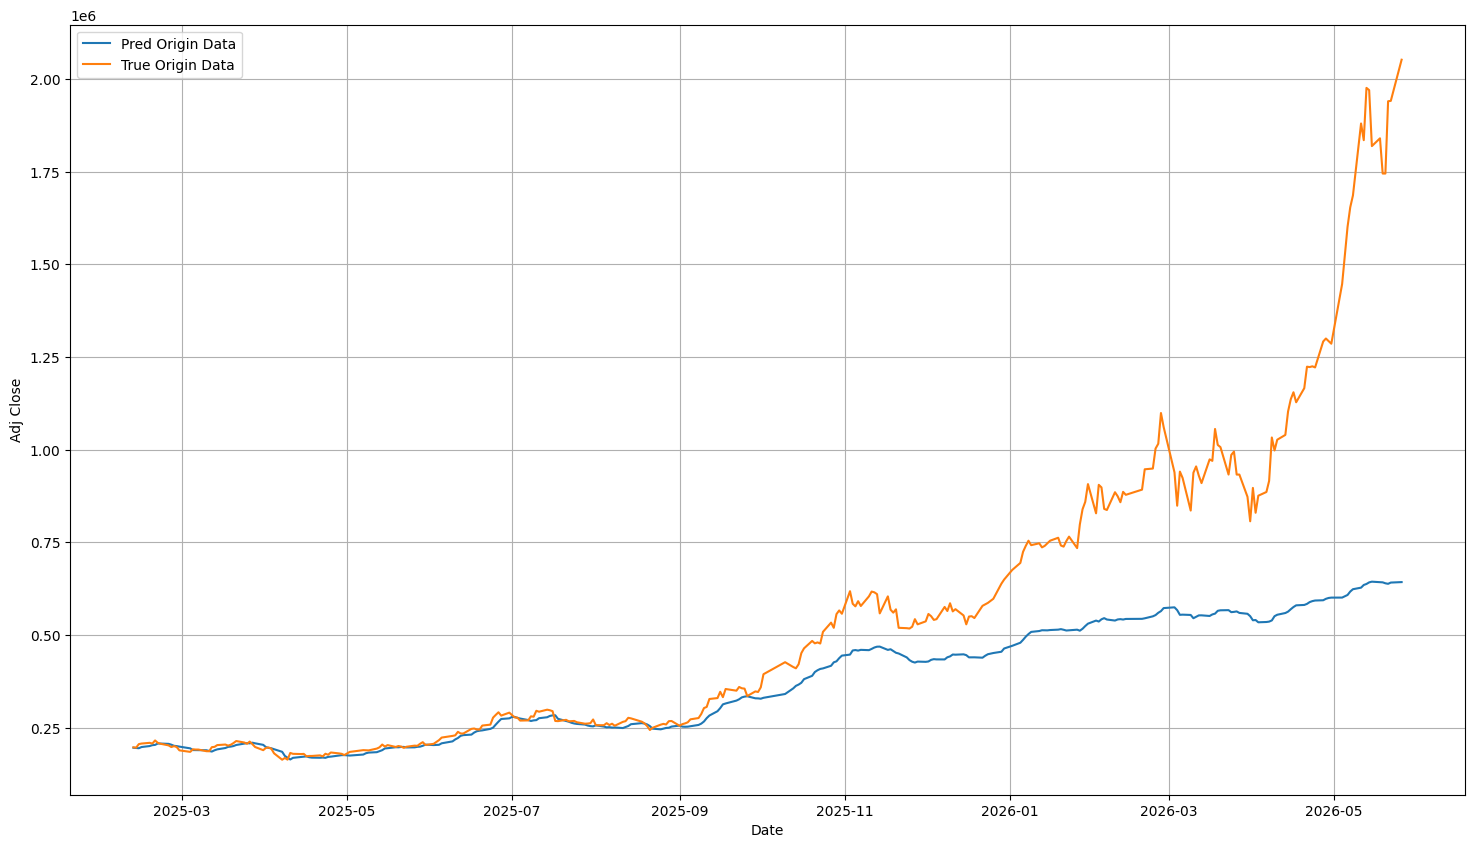

In [366]:
plt.figure(figsize=(18, 10))
# x축에서 사용될 시간축 데이터를 로드 
x_data = df['Date'].values[split_idx + window : ]

plt.plot(x_data, preds_origin, label='Pred Origin Data')
plt.plot(x_data, trues_origin, label='True Origin Data')

plt.legend()
plt.grid(True)
plt.ylabel('Adj Close')
plt.xlabel('Date')
plt.savefig('하이닉스 모델.png')
plt.show()